In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Charger les données
import os
chemin = r"D:\Nouveau dossier\Prototypage\transactions.jsonl"
df = pd.read_json(chemin, lines=True)
print(f"1. Chargé : {len(df)} transactions")

# 2. Convertir timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 3. Extraire heure et jour
df['heure'] = df['timestamp'].dt.hour
df['jour_semaine'] = df['timestamp'].dt.dayofweek

# 4. Encoder le canal (one-hot)
df_canal = pd.get_dummies(df['canal'], prefix='canal')

# 5. Extraire lat/lon depuis geolocalisation
df['lat'] = df['geolocalisation'].apply(lambda x: x['lat'] if isinstance(x, dict) else None)
df['lon'] = df['geolocalisation'].apply(lambda x: x['lon'] if isinstance(x, dict) else None)

# 6. Définir les colonnes de base
features_base = ['montant', 'heure', 'jour_semaine', 'duree_session_ms', 
                 'code_reponse', 'lat', 'lon']

# 7. Construire X (concaténation)
X = pd.concat([df[features_base], df_canal], axis=1)
X = X.fillna(0)
print(f"2. X créé : {X.shape[1]} features, {X.shape[0]} lignes")

# 8. Définir la cible y (anomalie = statut suspect ou erreur)
df['is_anomaly'] = df['statut'].isin(['suspect', 'erreur']).astype(int)
y = df['is_anomaly']
print(f"3. Anomalies : {y.sum()} sur {len(y)} ({y.mean():.2%})")

# 9. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("4. Normalisation terminée")

# 10. Séparation train/test (optionnelle pour l'instant)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"5. Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

1. Chargé : 1000 transactions
2. X créé : 12 features, 1000 lignes
3. Anomalies : 102 sur 1000 (10.20%)
4. Normalisation terminée
5. Train : 700 | Test : 300


1. Entraînement du modèle...
   Terminé.

2. Évaluation sur l'ensemble de test :
----------------------------------------
Matrice de confusion :
[[262   7]
 [ 16  15]]

Précision : 0.6818
Rappel    : 0.4839
F1-score  : 0.5660

Rapport de classification :
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.96       269
    Anomalie       0.68      0.48      0.57        31

    accuracy                           0.92       300
   macro avg       0.81      0.73      0.76       300
weighted avg       0.92      0.92      0.92       300



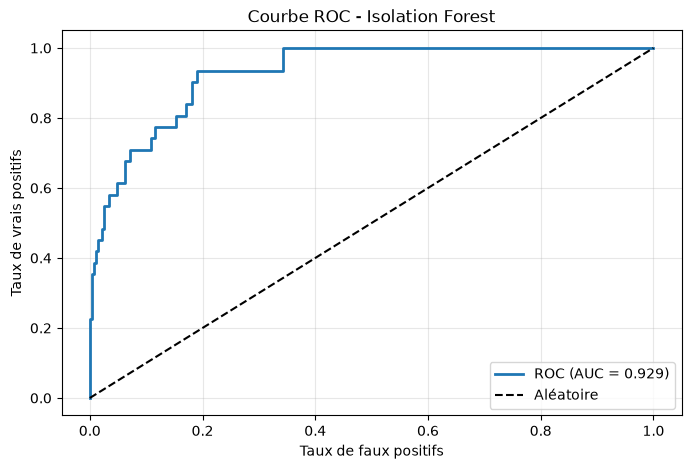


3. Modèle sauvegardé : isolation_forest_model.pkl


In [6]:
# =============================================
# SESSION 2 – Entraînement et évaluation
# =============================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Instancier le modèle
# contamination = proportion estimée d'anomalies (ici 0.05 = 5%)
model = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)

print("1. Entraînement du modèle...")
model.fit(X_train)
print("   Terminé.")

# 2. Prédire sur l'ensemble de TEST
y_pred_test = model.predict(X_test)
# Convertir : -1 (anomalie) -> 1, 1 (normal) -> 0
y_pred_test_bin = (y_pred_test == -1).astype(int)

# 3. Métriques
print("\n2. Évaluation sur l'ensemble de test :")
print("-" * 40)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test_bin)
print("Matrice de confusion :")
print(cm)

# Précision, rappel, F1
print(f"\nPrécision : {precision_score(y_test, y_pred_test_bin):.4f}")
print(f"Rappel    : {recall_score(y_test, y_pred_test_bin):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_test_bin):.4f}")

# Rapport complet
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_bin, target_names=['Normal', 'Anomalie']))

# 4. Courbe ROC
# Pour Isolation Forest, decision_function donne un score : plus il est négatif, plus c'est anormal.
# On inverse pour que plus le score soit élevé, plus c'est anormal (compatible avec ROC).
scores_test = -model.decision_function(X_test)
fpr, tpr, seuils = roc_curve(y_test, scores_test)
auc = roc_auc_score(y_test, scores_test)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC - Isolation Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Sauvegarder le modèle
joblib.dump(model, 'isolation_forest_model.pkl')
print("\n3. Modèle sauvegardé : isolation_forest_model.pkl")

1. Recherche des meilleurs paramètres...

contamination=0.02, n_estimators=50 → F1=0.4878, Rappel=0.3226, Précision=1.0000, Temps=4.44s
contamination=0.02, n_estimators=100 → F1=0.4762, Rappel=0.3226, Précision=0.9091, Temps=2.36s
contamination=0.02, n_estimators=200 → F1=0.4000, Rappel=0.2581, Précision=0.8889, Temps=3.83s
contamination=0.02, n_estimators=300 → F1=0.4000, Rappel=0.2581, Précision=0.8889, Temps=4.07s
contamination=0.05, n_estimators=50 → F1=0.6531, Rappel=0.5161, Précision=0.8889, Temps=0.94s
contamination=0.05, n_estimators=100 → F1=0.5660, Rappel=0.4839, Précision=0.6818, Temps=1.69s
contamination=0.05, n_estimators=200 → F1=0.6000, Rappel=0.4839, Précision=0.7895, Temps=3.20s
contamination=0.05, n_estimators=300 → F1=0.6122, Rappel=0.4839, Précision=0.8333, Temps=4.16s
contamination=0.1, n_estimators=50 → F1=0.7164, Rappel=0.7742, Précision=0.6667, Temps=0.65s
contamination=0.1, n_estimators=100 → F1=0.6032, Rappel=0.6129, Précision=0.5938, Temps=1.04s
contamination

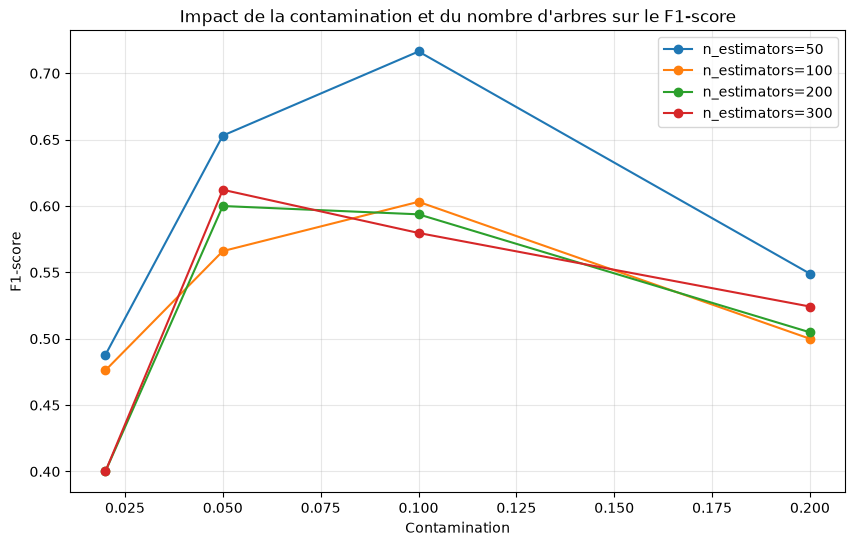

In [9]:
# =============================================
# SESSION 3 – Optimisation des hyperparamètres
# =============================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, recall_score, precision_score
import pandas as pd
import numpy as np
import time

# 1. Définir les paramètres à tester
parametres = {
    'contamination': [0.02, 0.05, 0.10, 0.20],
    'n_estimators': [50, 100, 200, 300]
}

# Stocker les résultats
resultats = []

print("1. Recherche des meilleurs paramètres...\n")

# 2. Boucle manuelle sur les paramètres
for cont in parametres['contamination']:
    for n_est in parametres['n_estimators']:
        start_time = time.time()
        
        # Instancier et entraîner
        model = IsolationForest(
            contamination=cont,
            random_state=42,
            n_estimators=n_est
        )
        model.fit(X_train)
        
        # Prédire sur test
        y_pred = model.predict(X_test)
        y_pred_bin = (y_pred == -1).astype(int)
        
        # Calculer les métriques
        f1 = f1_score(y_test, y_pred_bin)
        recall = recall_score(y_test, y_pred_bin)
        precision = precision_score(y_test, y_pred_bin)
        
        # Temps d'entraînement
        temps = time.time() - start_time
        
        # Stocker
        resultats.append({
            'contamination': cont,
            'n_estimators': n_est,
            'f1_score': f1,
            'recall': recall,
            'precision': precision,
            'temps (s)': round(temps, 2)
        })
        
        print(f"contamination={cont}, n_estimators={n_est} → F1={f1:.4f}, Rappel={recall:.4f}, Précision={precision:.4f}, Temps={temps:.2f}s")

# 3. Afficher le tableau des résultats
print("\n2. Résumé des résultats :")
df_resultats = pd.DataFrame(resultats)
print(df_resultats.to_string(index=False))

# 4. Meilleurs paramètres (maximiser le F1-score)
meilleur = df_resultats.loc[df_resultats['f1_score'].idxmax()]
print(f"\n3. Meilleure combinaison (selon F1-score) :")
print(f"   Contamination : {meilleur['contamination']}")
print(f"   n_estimators  : {meilleur['n_estimators']}")
print(f"   F1-score      : {meilleur['f1_score']:.4f}")
print(f"   Rappel        : {meilleur['recall']:.4f}")
print(f"   Précision     : {meilleur['precision']:.4f}")

# 5. Réentraîner avec les meilleurs paramètres sur l'ensemble du train
print("\n4. Réentraînement du modèle final avec les meilleurs paramètres...")
model_final = IsolationForest(
    contamination=meilleur['contamination'],
    random_state=42,
    n_estimators=int(meilleur['n_estimators'])
)
model_final.fit(X_train)

# 6. Évaluation finale sur test
y_pred_final = model_final.predict(X_test)
y_pred_final_bin = (y_pred_final == -1).astype(int)

print(f"   F1-score final : {f1_score(y_test, y_pred_final_bin):.4f}")
print(f"   Rappel final   : {recall_score(y_test, y_pred_final_bin):.4f}")
print(f"   Précision final: {precision_score(y_test, y_pred_final_bin):.4f}")

# 7. Sauvegarde du meilleur modèle
import joblib
joblib.dump(model_final, 'isolation_forest_model_optimise.pkl')
print("\n5. Modèle optimisé sauvegardé : isolation_forest_model_optimise.pkl")

# 8. Graphique comparatif des F1-score par contamination
plt.figure(figsize=(10, 6))
for n_est in parametres['n_estimators']:
    sous_df = df_resultats[df_resultats['n_estimators'] == n_est]
    plt.plot(sous_df['contamination'], sous_df['f1_score'], 
             marker='o', label=f'n_estimators={n_est}')

plt.xlabel('Contamination')
plt.ylabel('F1-score')
plt.title('Impact de la contamination et du nombre d\'arbres sur le F1-score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

✅ Modèle et scaler sauvegardés.


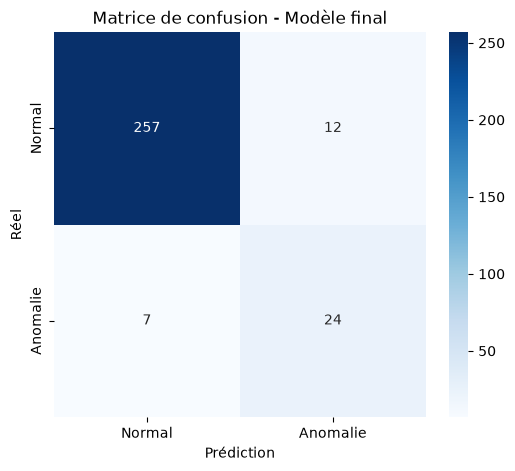


=== RAPPORT DE CLASSIFICATION (TEST) ===
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.96       269
    Anomalie       0.67      0.77      0.72        31

    accuracy                           0.94       300
   macro avg       0.82      0.86      0.84       300
weighted avg       0.94      0.94      0.94       300



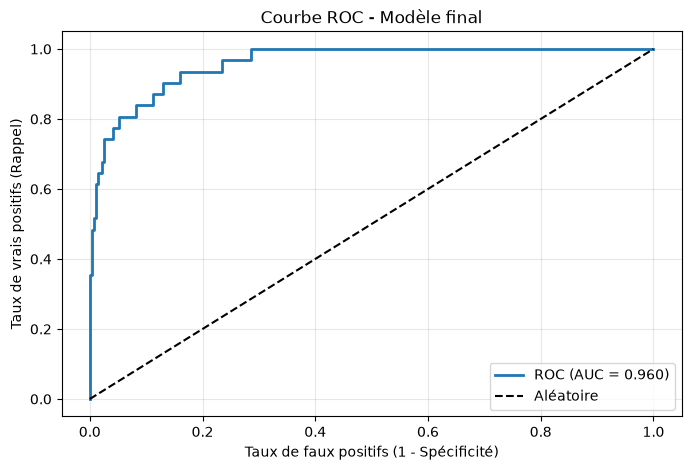


=== RÉSUMÉ DES PERFORMANCES ===
 Métrique   Valeur
Précision 0.666667
   Rappel 0.774194
 F1-score 0.716418
      AUC 0.959947

=== INTERPRÉTATION ===
✅ Le modèle détecte 77.4% des anomalies réelles (rappel).
✅ Parmi les alertes générées, 66.7% sont de vraies anomalies (précision).
✅ Le F1-score de 0.716 indique un bon équilibre entre précision et rappel.
✅ L'AUC de 0.960 montre que le modèle distingue bien les normaux des anomalies.

=== HYPERPARAMÈTRES FINAUX ===
Contamination : 0.1
Nombre d'arbres : 50
Random state : 42


In [10]:
# =============================================
# SESSION 4 – Sauvegarde du modèle et rapport final
# =============================================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# 1. Sauvegarder le modèle final ET le scaler
# (Le scaler est important pour normaliser les futures données de la même manière)
joblib.dump(model_final, 'isolation_forest_model_final.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Modèle et scaler sauvegardés.")

# 2. Évaluation finale sur l'ensemble de test (si pas déjà fait)
y_pred_final = model_final.predict(X_test)
y_pred_final_bin = (y_pred_final == -1).astype(int)

# 3. Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final_bin)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomalie'], 
            yticklabels=['Normal', 'Anomalie'])
plt.title('Matrice de confusion - Modèle final')
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.show()

# 4. Rapport de classification
print("\n=== RAPPORT DE CLASSIFICATION (TEST) ===")
print(classification_report(y_test, y_pred_final_bin, target_names=['Normal', 'Anomalie']))

# 5. Courbe ROC (si pas déjà tracée)
scores_test = -model_final.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, scores_test)
auc = roc_auc_score(y_test, scores_test)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de faux positifs (1 - Spécificité)')
plt.ylabel('Taux de vrais positifs (Rappel)')
plt.title('Courbe ROC - Modèle final')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Résumé des performances (tableau récapitulatif)
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_final_bin)
recall = recall_score(y_test, y_pred_final_bin)
f1 = f1_score(y_test, y_pred_final_bin)

resume = pd.DataFrame({
    'Métrique': ['Précision', 'Rappel', 'F1-score', 'AUC'],
    'Valeur': [precision, recall, f1, auc]
})
print("\n=== RÉSUMÉ DES PERFORMANCES ===")
print(resume.to_string(index=False))

# 7. Interprétation (à adapter selon tes résultats)
print("\n=== INTERPRÉTATION ===")
print(f"✅ Le modèle détecte {recall*100:.1f}% des anomalies réelles (rappel).")
print(f"✅ Parmi les alertes générées, {precision*100:.1f}% sont de vraies anomalies (précision).")
print(f"✅ Le F1-score de {f1:.3f} indique un bon équilibre entre précision et rappel.")
print(f"✅ L'AUC de {auc:.3f} montre que le modèle distingue bien les normaux des anomalies.")

# 8. Synthèse des hyperparamètres choisis
print("\n=== HYPERPARAMÈTRES FINAUX ===")
print(f"Contamination : {model_final.contamination}")
print(f"Nombre d'arbres : {model_final.n_estimators}")
print(f"Random state : {model_final.random_state}")